In [ ]:
!nvidia-smi


Thu Jul 30 12:09:59 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   47C    P8             12W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [13]:
from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [14]:
import os

path = "/content/drive/MyDrive/Colab Notebooks"

print(os.listdir(path))

['Project_AI.ipynb', 'Classroom Person Detection']


In [15]:
DRIVE_DATASET = "/content/drive/MyDrive/Colab Notebooks/Classroom Person Detection"

print("Folder exists:", os.path.exists(DRIVE_DATASET))
print(os.listdir(DRIVE_DATASET))

Folder exists: True
['README.dataset.txt', 'README.roboflow.txt', 'data.yaml', 'test', 'train', 'valid']


In [16]:
import os

folders_to_check = [
    "train/images",
    "train/labels",
    "valid/images",
    "valid/labels",
    "test/images",
    "test/labels"
]

for folder in folders_to_check:
    full_path = os.path.join(DRIVE_DATASET, folder)
    print(folder, "→", os.path.exists(full_path))

train/images → True
train/labels → True
valid/images → True
valid/labels → True
test/images → True
test/labels → True


In [17]:
import shutil
import os

LOCAL_DATASET = "/content/classroom_dataset"

if os.path.exists(LOCAL_DATASET):
    shutil.rmtree(LOCAL_DATASET)

shutil.copytree(DRIVE_DATASET, LOCAL_DATASET)

print("Dataset copied successfully")
print(os.listdir(LOCAL_DATASET))

Dataset copied successfully
['data.yaml', 'train', 'test', 'README.roboflow.txt', 'valid', 'README.dataset.txt']


In [18]:
from pathlib import Path

image_extensions = ["*.jpg", "*.jpeg", "*.png", "*.bmp", "*.webp"]

def count_images(folder):
    folder = Path(folder)
    return sum(len(list(folder.glob(extension))) for extension in image_extensions)

for split in ["train", "valid", "test"]:
    image_folder = Path(LOCAL_DATASET) / split / "images"
    label_folder = Path(LOCAL_DATASET) / split / "labels"

    image_count = count_images(image_folder) if image_folder.exists() else 0
    label_count = len(list(label_folder.glob("*.txt"))) if label_folder.exists() else 0

    print(f"{split}: {image_count} images, {label_count} labels")

train: 680 images, 680 labels
valid: 149 images, 149 labels
test: 74 images, 74 labels


In [19]:
DATA_YAML = f"{LOCAL_DATASET}/data.yaml"

with open(DATA_YAML, "r") as file:
    print(file.read())

train: ../train/images
val: ../valid/images
test: ../test/images

nc: 2
names: ['cleaner', 'person']

roboflow:
  workspace: sangavi-sriranganathan
  project: classroom-person-detection-pvi9l
  version: dataset
  license: CC BY 4.0
  url: https://universe.roboflow.com/sangavi-sriranganathan/classroom-person-detection-pvi9l/dataset/dataset


In [20]:
import yaml
import os

original_yaml = os.path.join(LOCAL_DATASET, "data.yaml")

with open(original_yaml, "r") as file:
    original_data = yaml.safe_load(file)

print("Original class names:", original_data.get("names"))

Original class names: ['cleaner', 'person']


In [21]:
class_names = original_data.get("names")

fixed_data = {
    "path": LOCAL_DATASET,
    "train": "train/images",
    "val": "valid/images",
    "test": "test/images",
    "nc": len(class_names),
    "names": class_names
}

FIXED_YAML = os.path.join(LOCAL_DATASET, "data_fixed.yaml")

with open(FIXED_YAML, "w") as file:
    yaml.dump(fixed_data, file, sort_keys=False)

print("New YAML created:", FIXED_YAML)

with open(FIXED_YAML, "r") as file:
    print(file.read())

New YAML created: /content/classroom_dataset/data_fixed.yaml
path: /content/classroom_dataset
train: train/images
val: valid/images
test: test/images
nc: 2
names:
- cleaner
- person



In [22]:
!pip install -q ultralytics

In [23]:
import ultralytics

ultralytics.checks()

Ultralytics 8.4.112 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 49.4/112.6 GB disk)


In [24]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")

In [25]:
results = model.train(
    data=FIXED_YAML,
    epochs=50,
    imgsz=640,
    batch=16,
    device=0,
    workers=2,
    project="/content/runs",
    name="classroom_person_cleaner",
    patience=15,
    plots=True
)

Ultralytics 8.4.112 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/classroom_dataset/data_fixed.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=classroom_person_c

In [26]:
!ls "/content/runs/classroom_person_cleaner"

args.yaml			 results.csv	      val_batch0_labels.jpg
BoxF1_curve.png			 results.png	      val_batch0_pred.jpg
BoxP_curve.png			 train_batch0.jpg     val_batch1_labels.jpg
BoxPR_curve.png			 train_batch1720.jpg  val_batch1_pred.jpg
BoxR_curve.png			 train_batch1721.jpg  val_batch2_labels.jpg
confusion_matrix_normalized.png  train_batch1722.jpg  val_batch2_pred.jpg
confusion_matrix.png		 train_batch1.jpg     weights
labels.jpg			 train_batch2.jpg


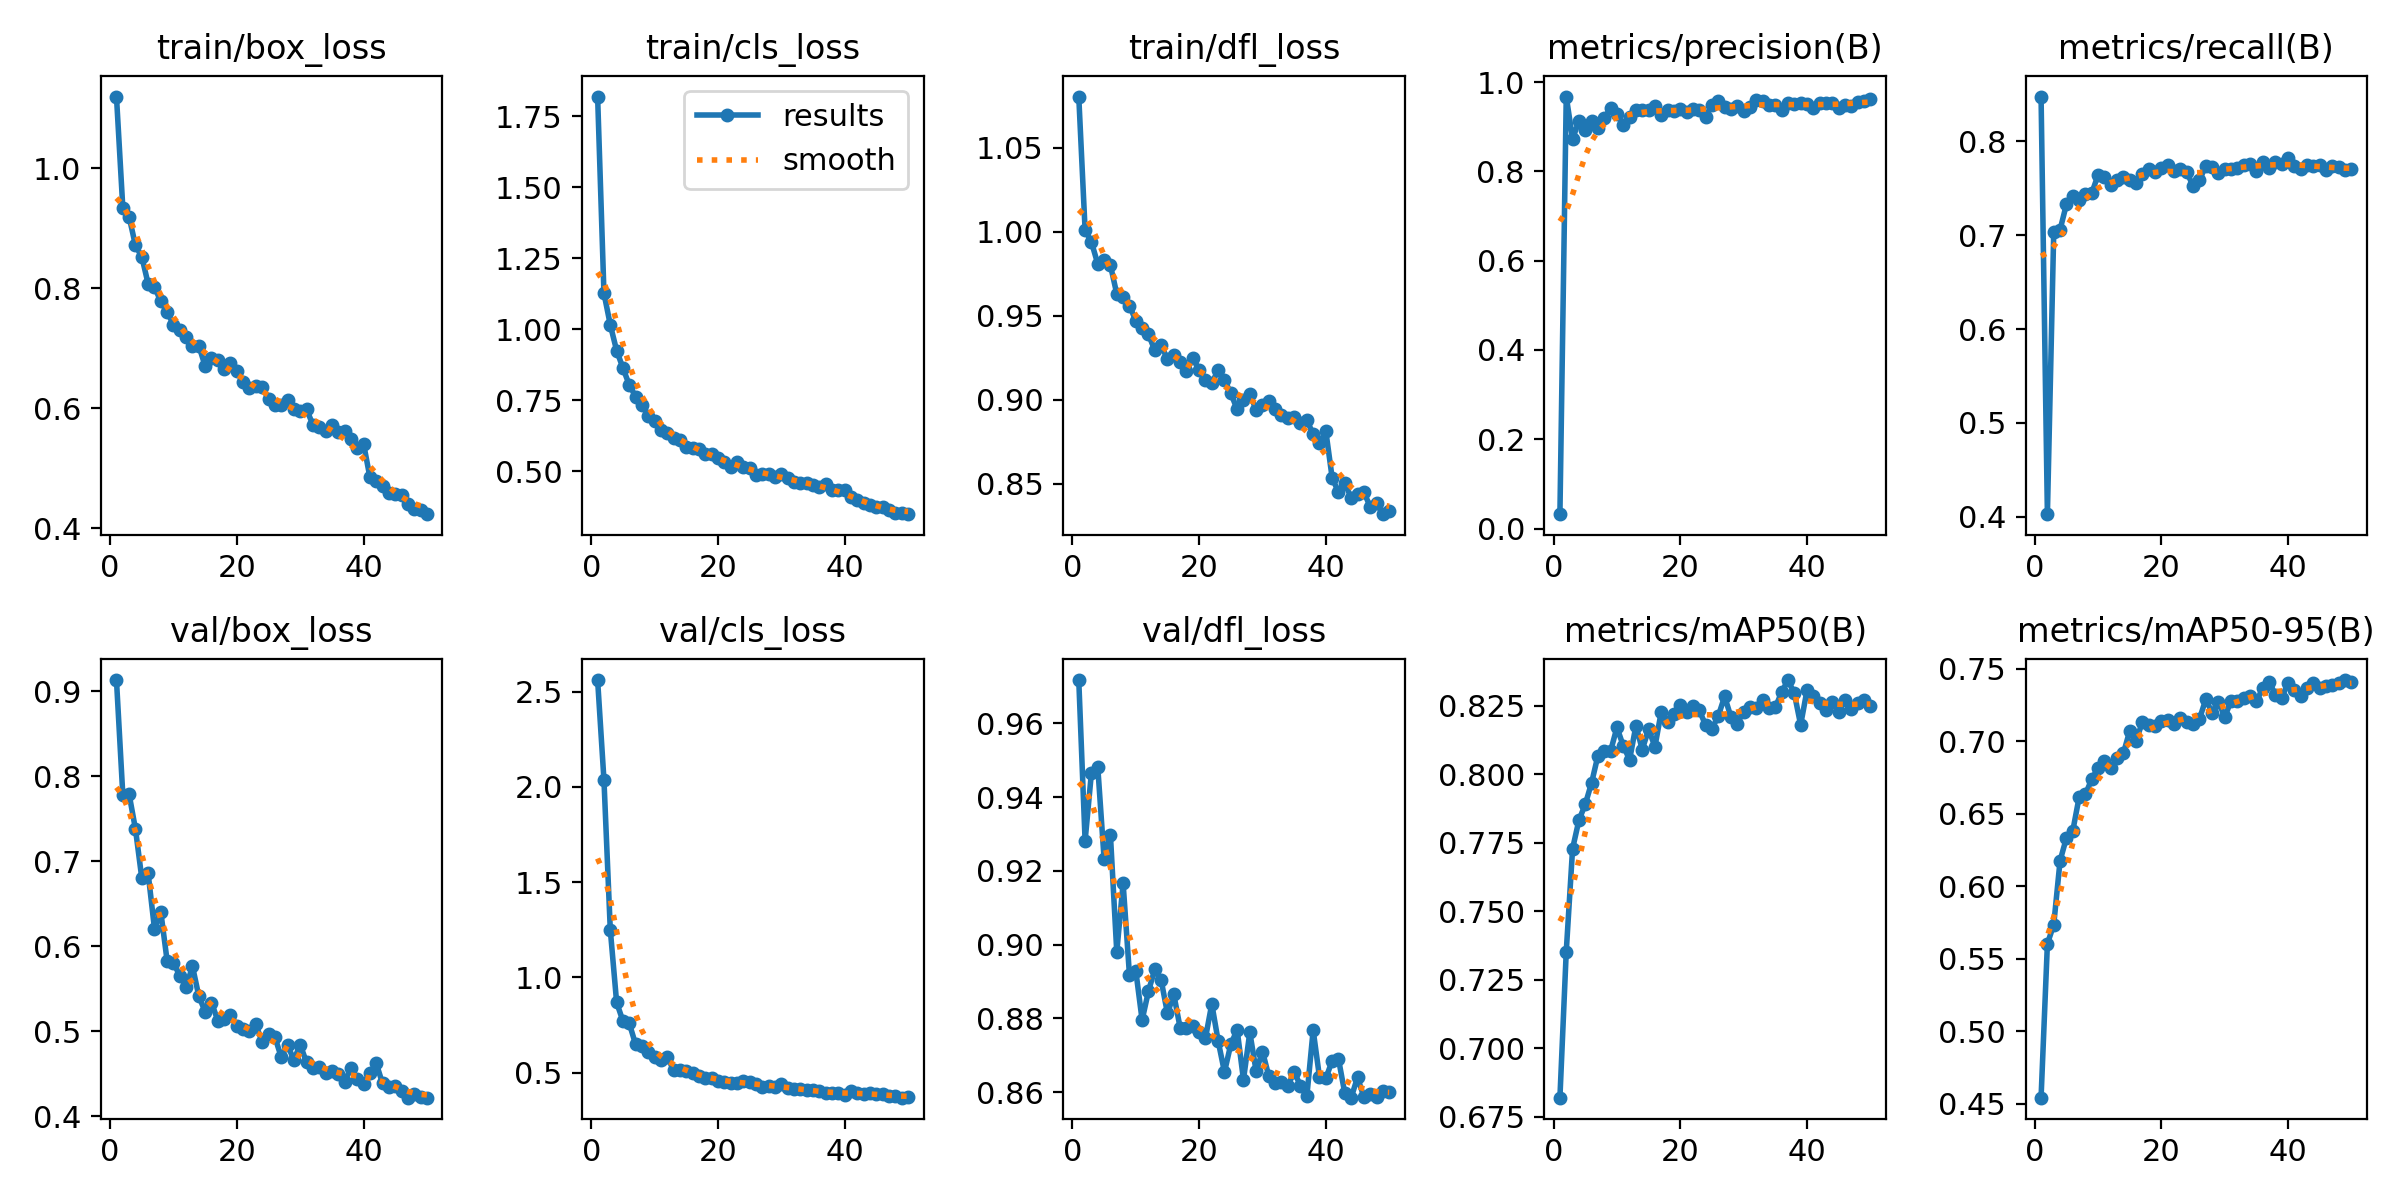

In [27]:
from IPython.display import Image, display

display(Image(
    filename="/content/runs/classroom_person_cleaner/results.png",
    width=900
))

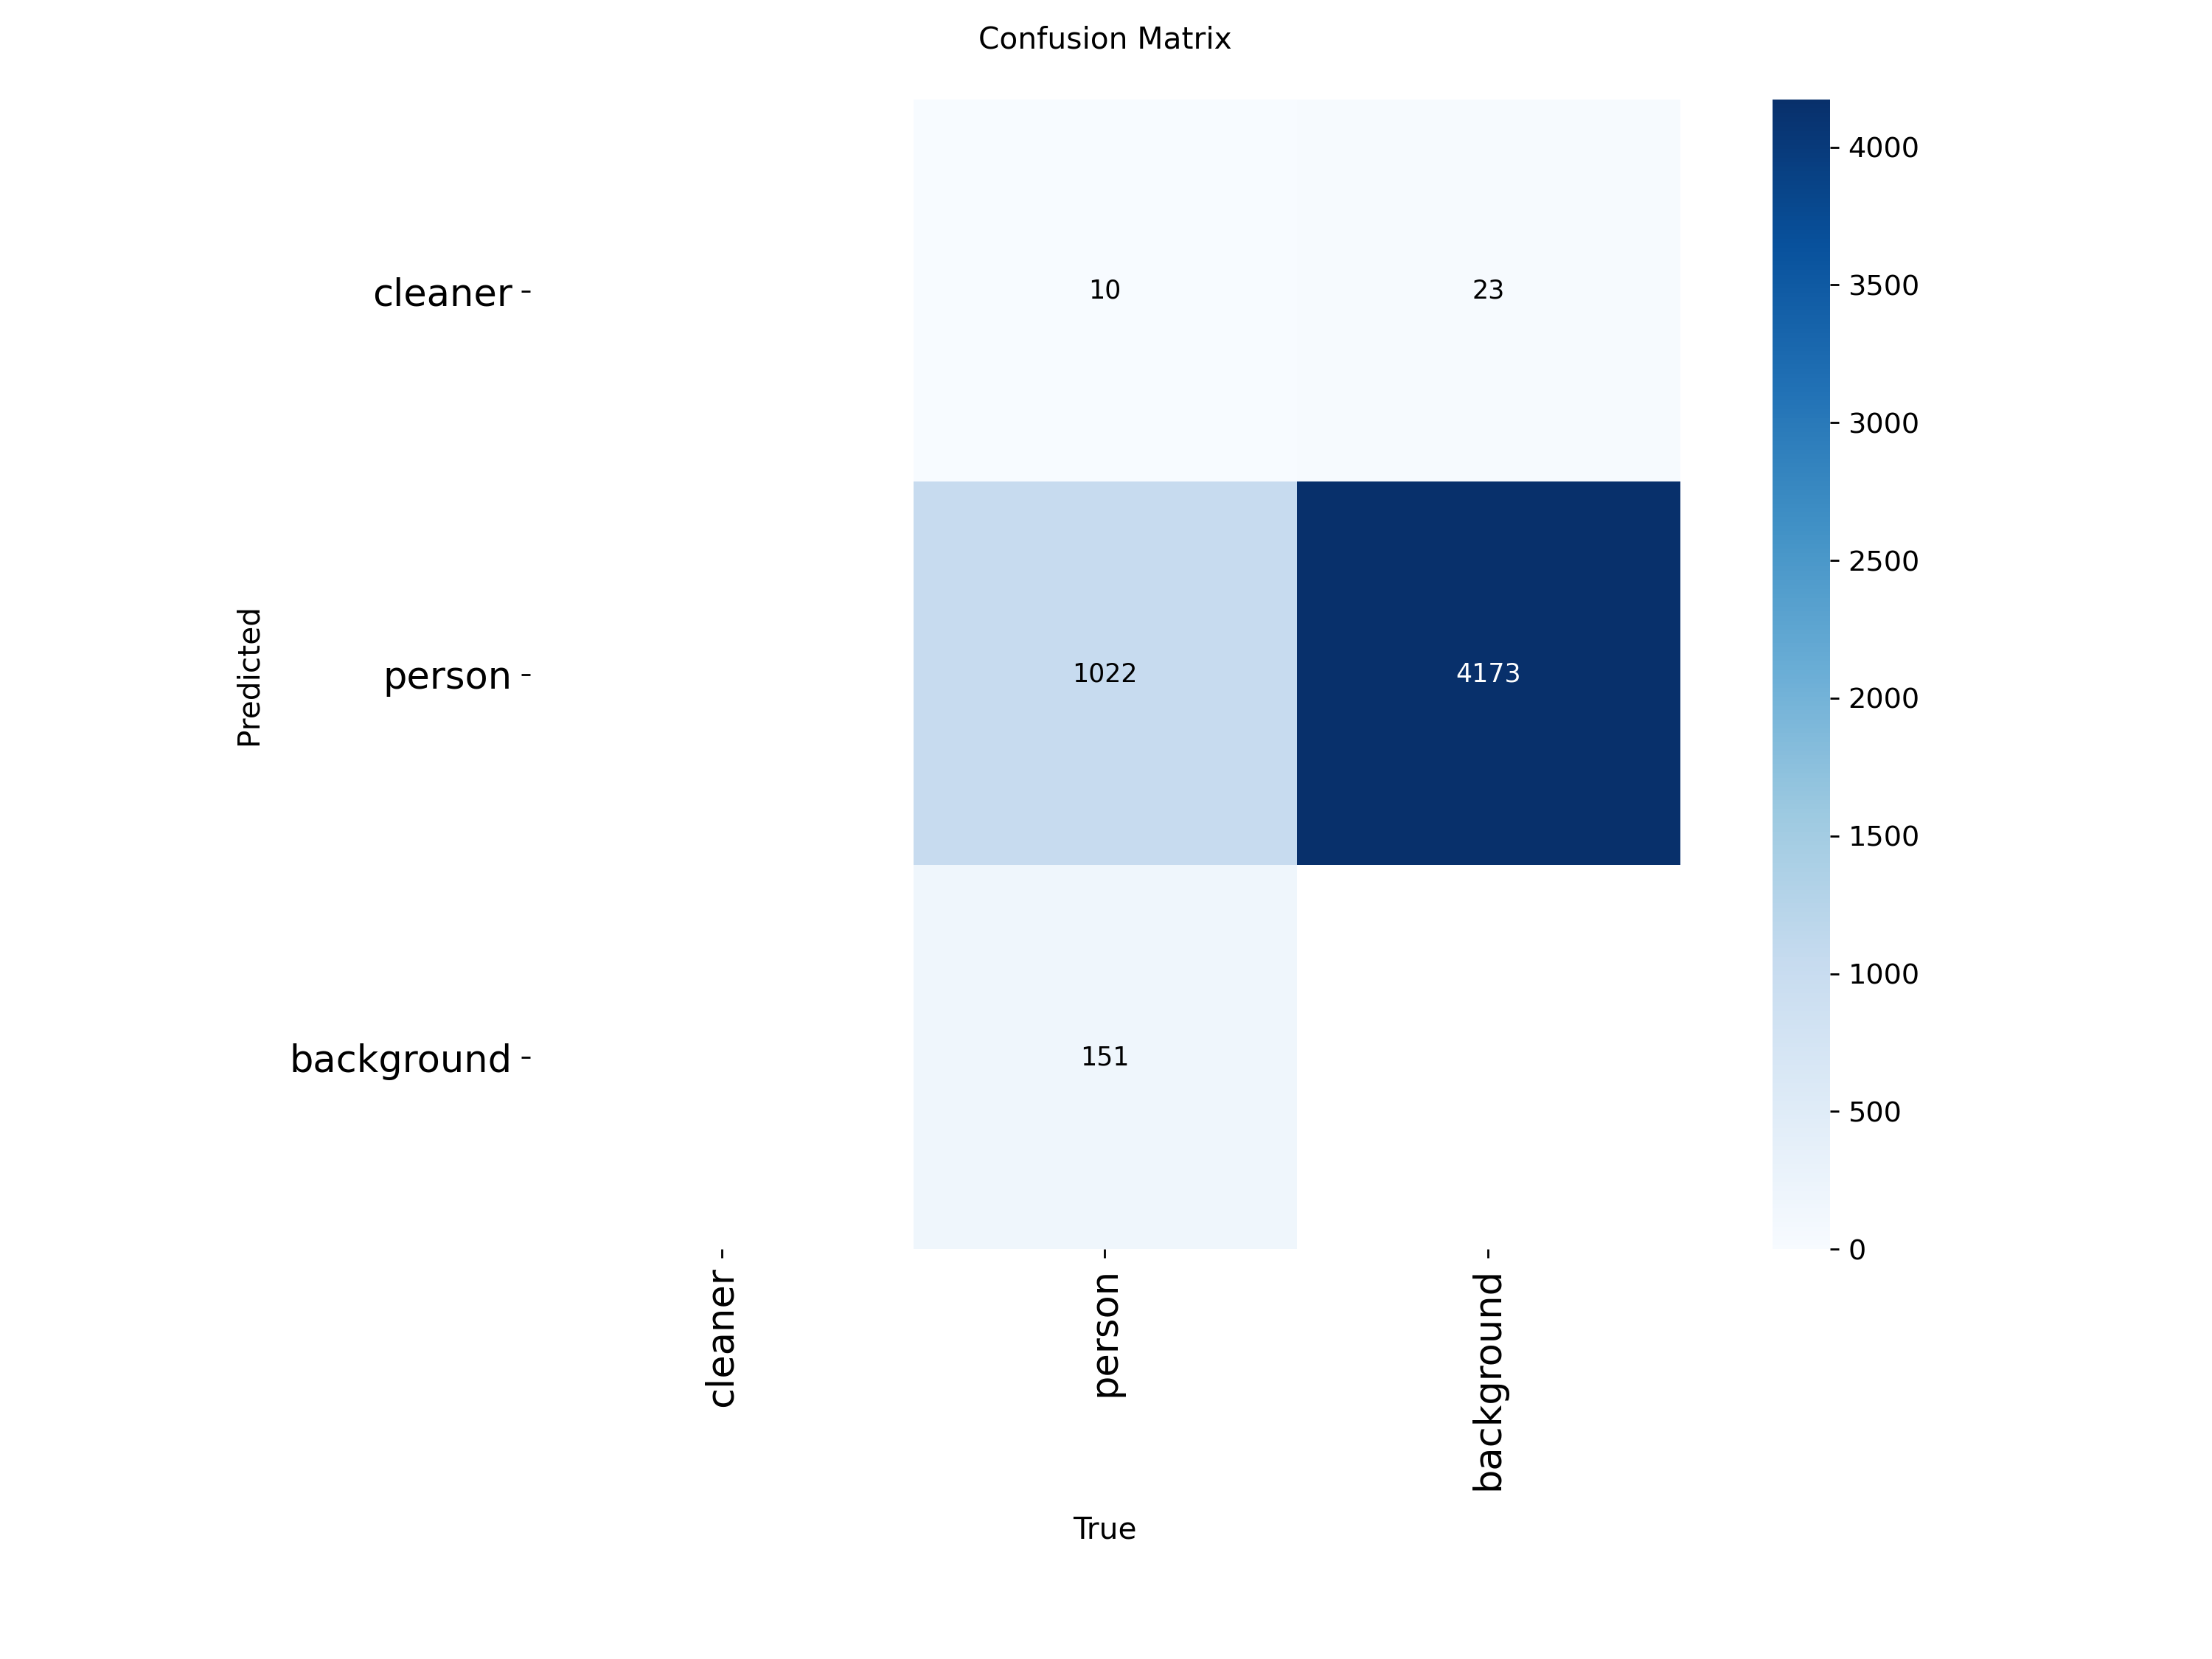

In [28]:
display(Image(
    filename="/content/runs/classroom_person_cleaner/confusion_matrix.png",
    width=700
))

In [29]:
from ultralytics import YOLO

best_model = YOLO(
    "/content/runs/classroom_person_cleaner/weights/best.pt"
)

metrics = best_model.val(
    data=FIXED_YAML,
    split="val"
)

Ultralytics 8.4.112 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,006,038 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 3979.2±1900.1 MB/s, size: 1468.3 KB)
val: Scanning /content/classroom_dataset/valid/labels.cache... 149 images, 8 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 149/149 41.7Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 10/10 1.2it/s 8.3s
                   all        149       1183      0.958      0.768      0.829      0.744
                person        141       1183      0.958      0.768      0.829      0.744
Speed: 3.1ms preprocess, 4.9ms inference, 0.0ms loss, 3.4ms postprocess per image
Results saved to /content/runs/detect/val


In [30]:
print("mAP50:", metrics.box.map50)
print("mAP50-95:", metrics.box.map)
print("Precision:", metrics.box.mp)
print("Recall:", metrics.box.mr)

mAP50: 0.8285043933133679
mAP50-95: 0.7435364152017031
Precision: 0.9575272178802583
Recall: 0.768385460693153


In [31]:
prediction_results = best_model.predict(
    source=f"{LOCAL_DATASET}/test/images",
    conf=0.25,
    imgsz=640,
    save=True,
    project="/content/predictions",
    name="test_results"
)


image 1/74 /content/classroom_dataset/test/images/IMG_3549_frame_000019_jpg.rf.eT955evJU0EmvNHWhA1Y.jpg: 384x640 2 persons, 5.5ms
image 2/74 /content/classroom_dataset/test/images/IMG_3549_frame_000020_jpg.rf.bL6XlKhzOfuo6EPcbmQ5.jpg: 384x640 2 persons, 6.6ms
image 3/74 /content/classroom_dataset/test/images/IMG_3551_frame_000009_jpg.rf.eETaZq6UMAz2apxjOr9q.jpg: 384x640 8 persons, 6.1ms
image 4/74 /content/classroom_dataset/test/images/IMG_3551_frame_000010_jpg.rf.TunfW4iJCoGIu1QnT7Ym.jpg: 384x640 8 persons, 6.0ms
image 5/74 /content/classroom_dataset/test/images/IMG_3551_frame_000015_jpg.rf.1XldOH3gu22mW5pVFM0C.jpg: 384x640 8 persons, 6.3ms
image 6/74 /content/classroom_dataset/test/images/IMG_3551_frame_000023_jpg.rf.NKSHJ3mBp0lJiN8FDXlF.jpg: 384x640 13 persons, 6.1ms
image 7/74 /content/classroom_dataset/test/images/IMG_3551_frame_000030_jpg.rf.TVrfsd7FWvkphE4UOi3p.jpg: 384x640 10 persons, 18.5ms
image 8/74 /content/classroom_dataset/test/images/IMG_3551_frame_000031_jpg.rf.PKclGNp

Predicted files: 74


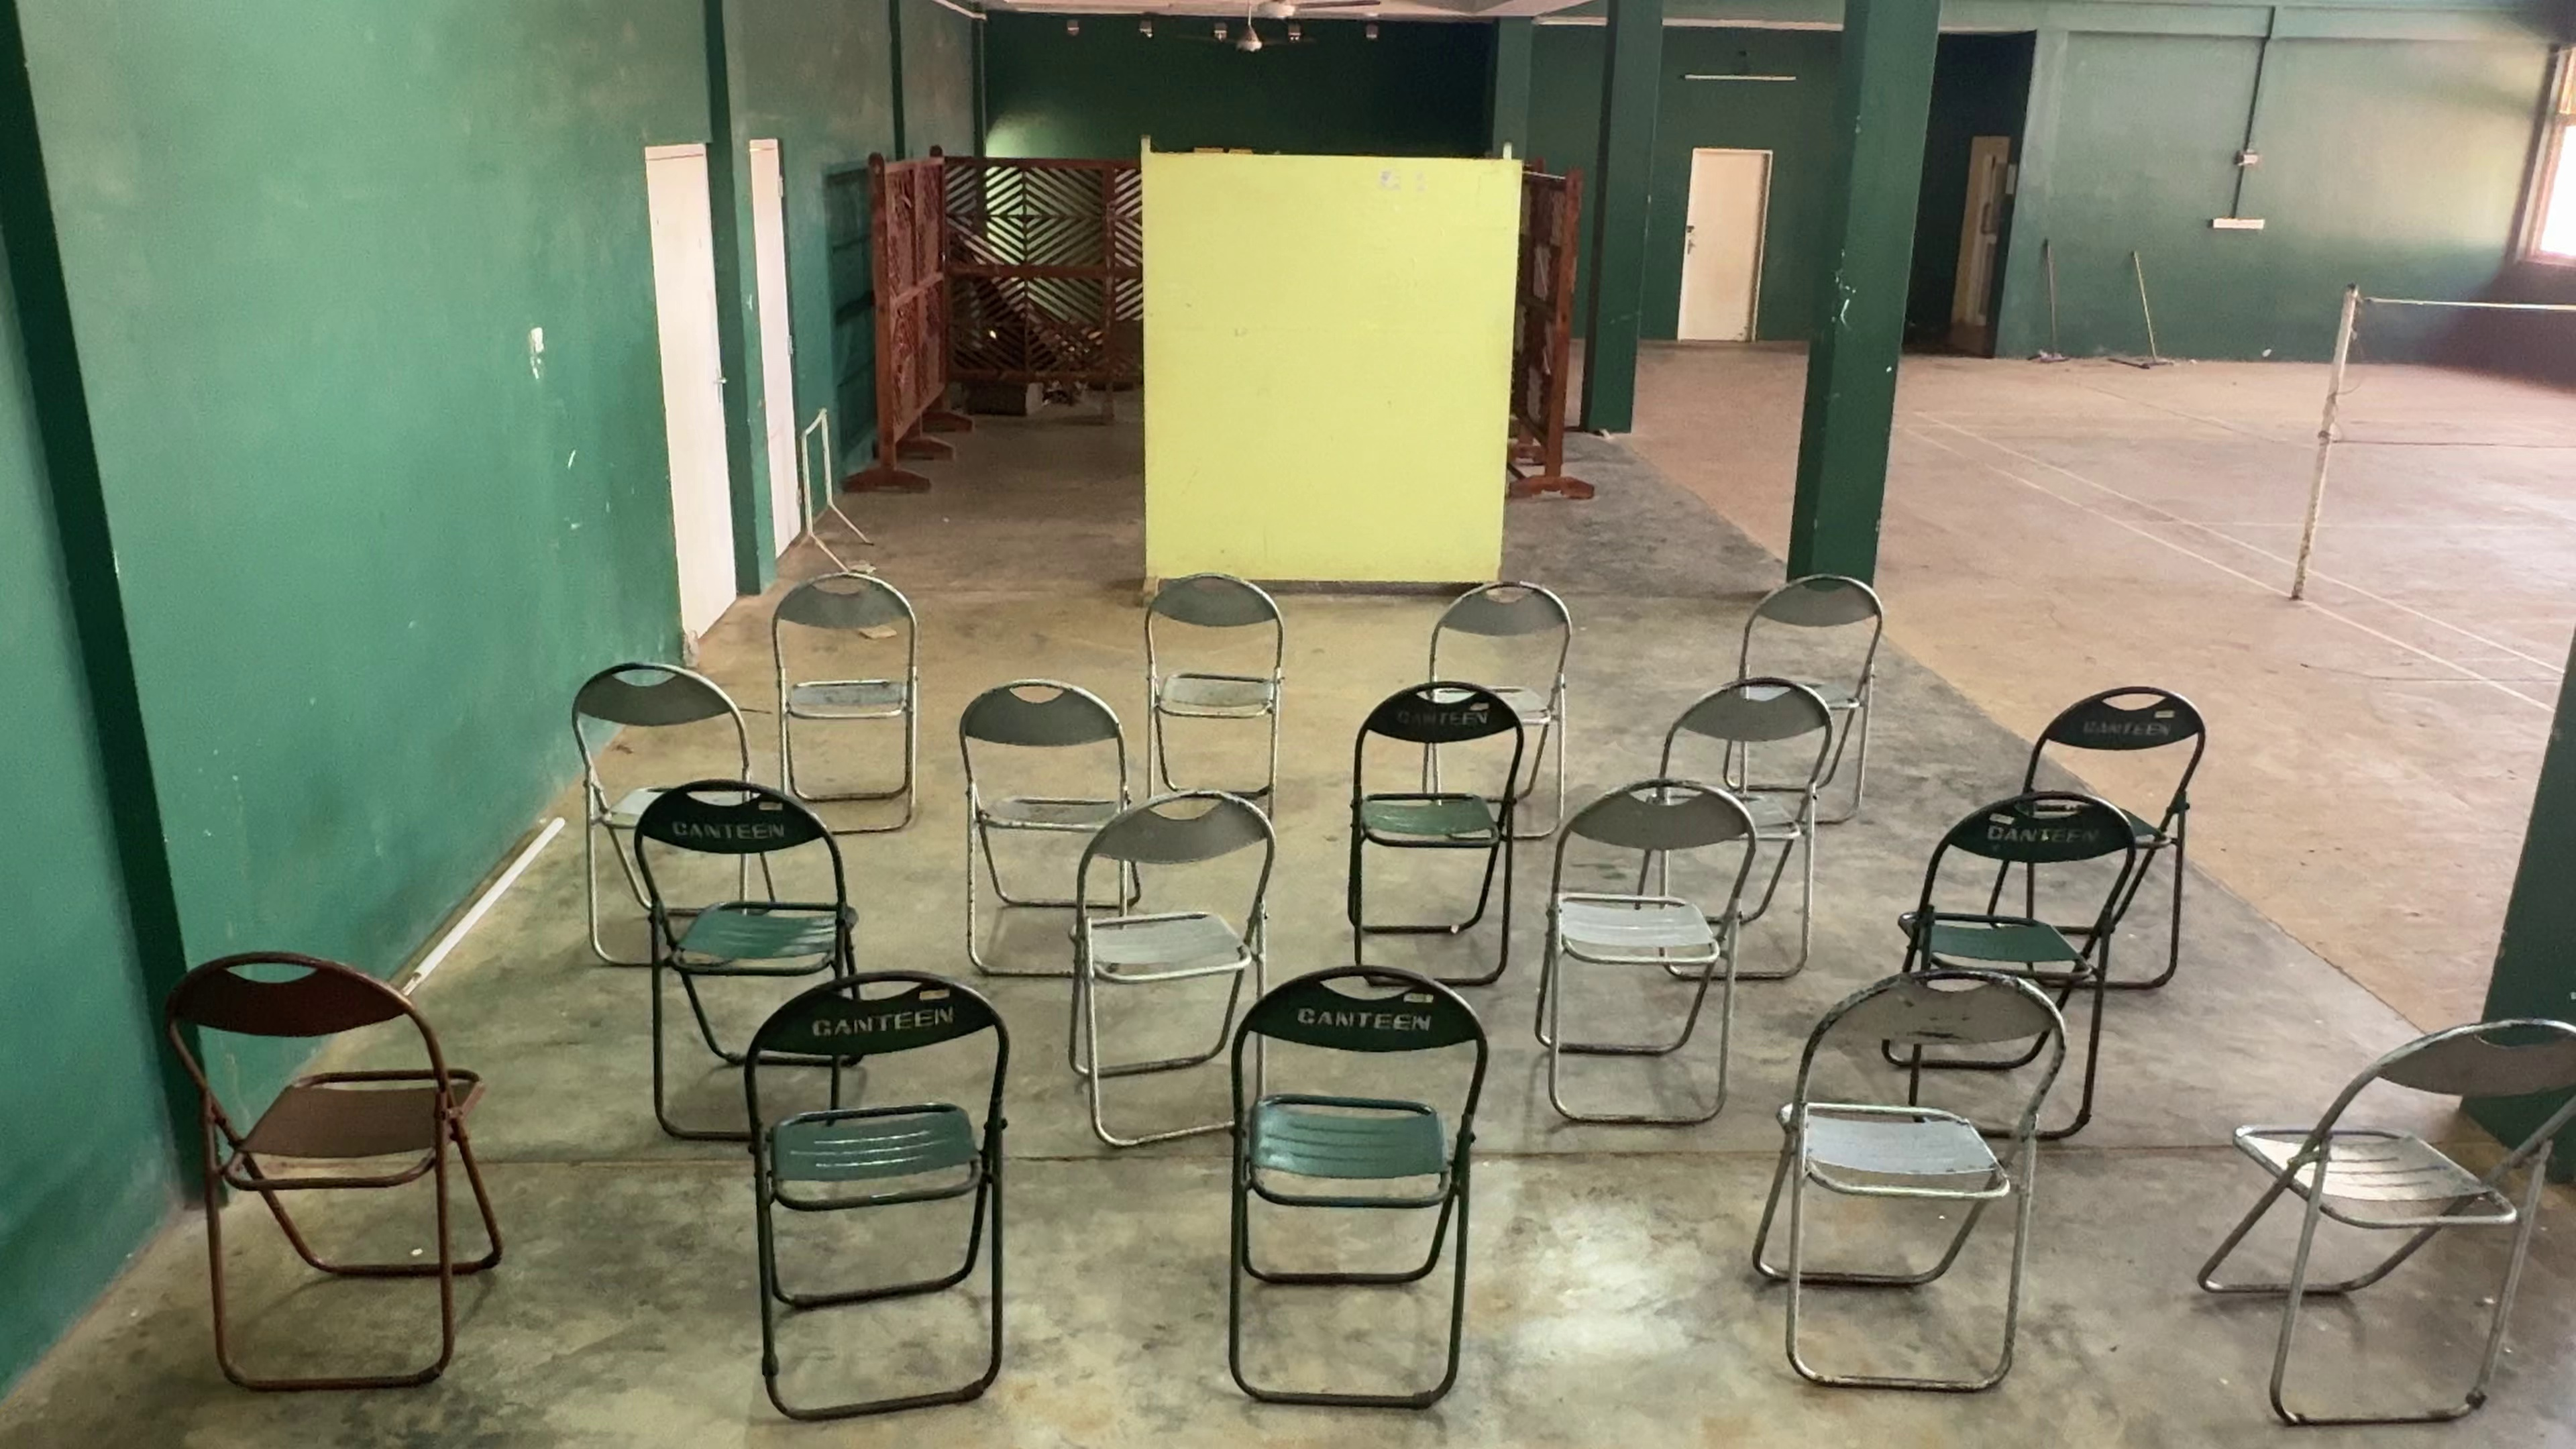

In [32]:
import glob
from IPython.display import Image, display

predicted_images = glob.glob(
    "/content/predictions/test_results/*"
)

print("Predicted files:", len(predicted_images))

if predicted_images:
    display(Image(filename=predicted_images[0], width=800))

In [35]:
import os

print(os.listdir("/content"))

['.config', 'classroom_dataset', 'yolov8n.pt', 'yolo26n.pt', 'IMG_3577_frame_000033.jpg', 'drive', 'predictions', 'runs', 'IMG_3577_frame_000018.jpg']


In [36]:
import os

model_path = "/content/runs/classroom_person_cleaner/weights/best.pt"

print("Model exists:", os.path.exists(model_path))

Model exists: True


In [37]:
from ultralytics import YOLO

best_model = YOLO("/content/runs/classroom_person_cleaner/weights/best.pt")

print("Model loaded successfully")

Model loaded successfully


In [38]:
import os

print(os.listdir("/content/runs"))

['classroom_person_cleaner', 'detect']


In [39]:
print(os.listdir("/content/runs/classroom_person_cleaner/weights"))

['best.pt', 'last.pt']


In [40]:
results = best_model.predict(
    source="/content/IMG_3577_frame_000033.jpg",
    conf=0.25,
    imgsz=640,
    save=True,
    project="/content/predictions",
    name="test_image"
)


image 1/1 /content/IMG_3577_frame_000033.jpg: 384x640 6 persons, 5.9ms
Speed: 2.4ms preprocess, 5.9ms inference, 1.3ms postprocess per image at shape (1, 3, 384, 640)
Results saved to /content/predictions/test_image


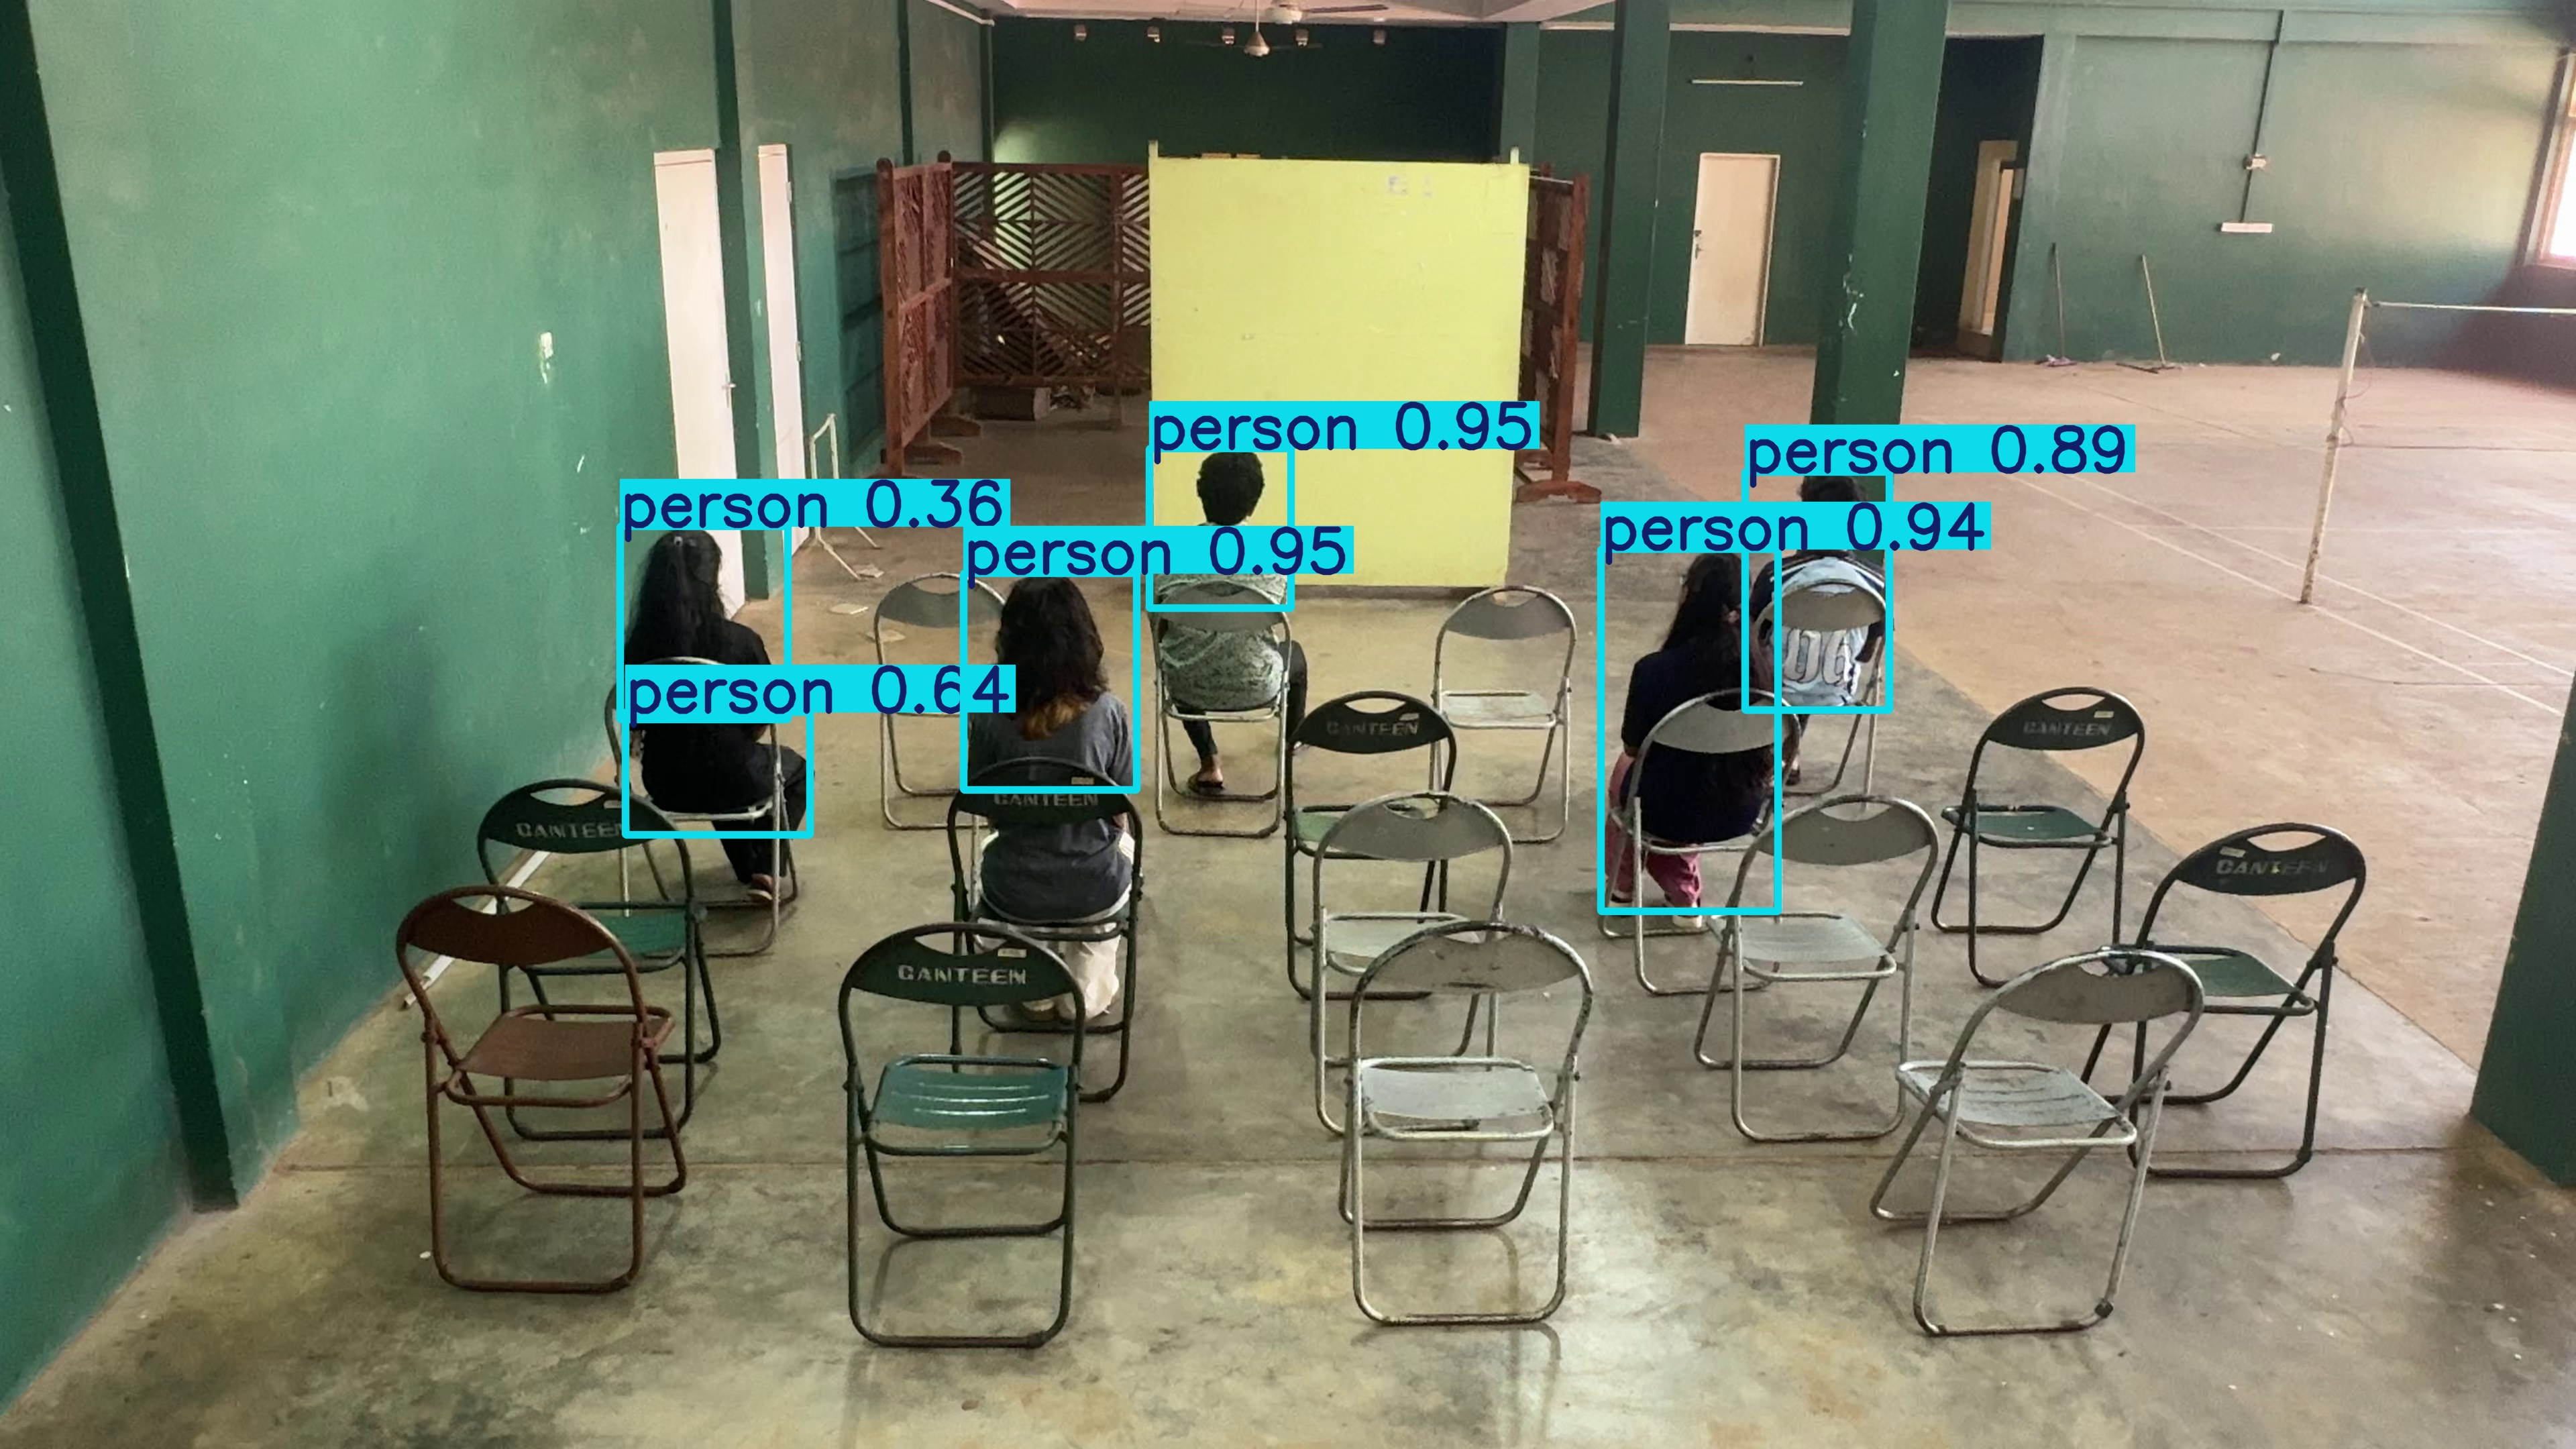

In [41]:
from IPython.display import Image, display

display(
    Image(
        filename="/content/predictions/test_image/IMG_3577_frame_000033.jpg",
        width=800
    )
)

In [42]:
results = best_model.predict(
    source="/content/IMG_3577_frame_000018.jpg",
    conf=0.25,
    imgsz=640,
    save=True,
    project="/content/predictions",
    name="test_image_2"
)


image 1/1 /content/IMG_3577_frame_000018.jpg: 384x640 6 persons, 6.4ms
Speed: 2.3ms preprocess, 6.4ms inference, 1.3ms postprocess per image at shape (1, 3, 384, 640)
Results saved to /content/predictions/test_image_2


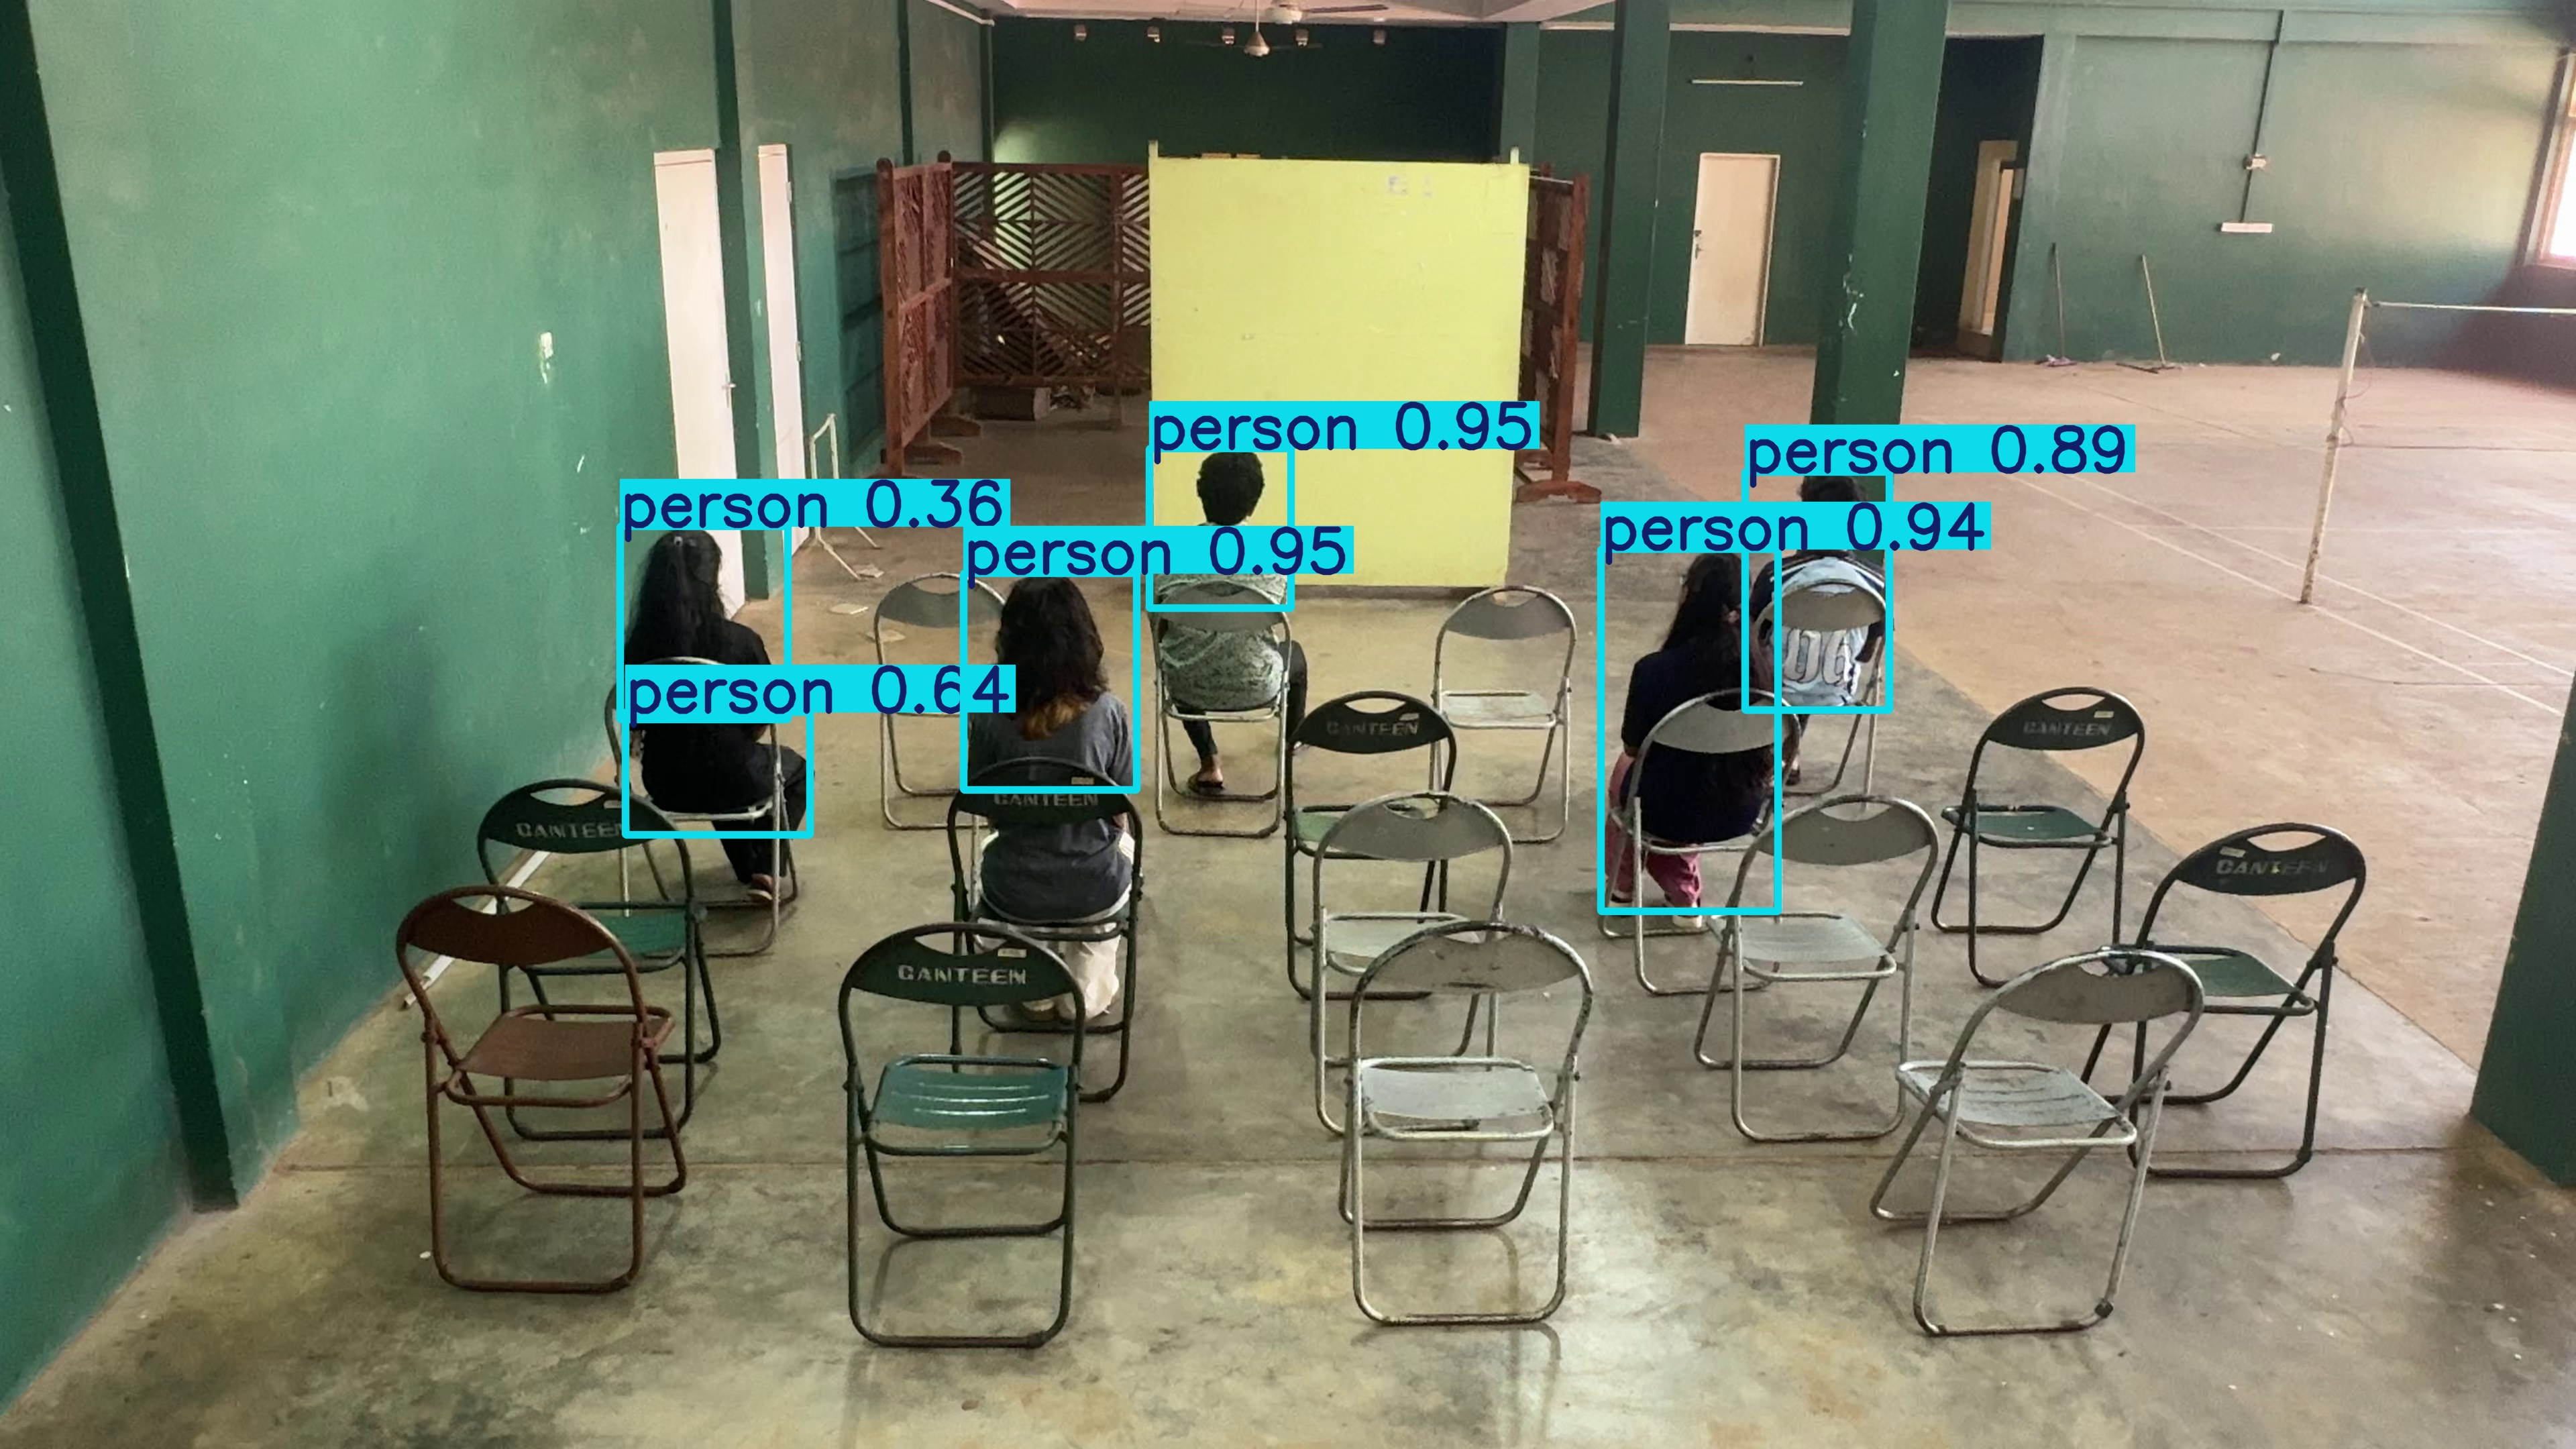

In [43]:
from IPython.display import Image, display

display(
    Image(
        filename="/content/predictions/test_image/IMG_3577_frame_000033.jpg",
        width=800
    )
)

In [44]:
import os
import shutil

SAVE_FOLDER = "/content/drive/MyDrive/Colab Notebooks/Trained Classroom Model"

os.makedirs(SAVE_FOLDER, exist_ok=True)

shutil.copy(
    "/content/runs/classroom_person_cleaner/weights/best.pt",
    f"{SAVE_FOLDER}/best.pt"
)

shutil.copy(
    "/content/runs/classroom_person_cleaner/weights/last.pt",
    f"{SAVE_FOLDER}/last.pt"
)

print("Models saved to:", SAVE_FOLDER)

Models saved to: /content/drive/MyDrive/Colab Notebooks/Trained Classroom Model


In [45]:
shutil.copy(
    "/content/runs/classroom_person_cleaner/results.png",
    f"{SAVE_FOLDER}/results.png"
)

shutil.copy(
    "/content/runs/classroom_person_cleaner/confusion_matrix.png",
    f"{SAVE_FOLDER}/confusion_matrix.png"
)

print("Results copied successfully")

Results copied successfully
